# 04 - Visual Reporting and Business Hand-off

**Project:** Credit card fraud prediction MVP.

**What this notebook does:** reloads the saved model, evaluates it once more on the
held-out test set, exports three performance charts to `reports/figures/`, and
writes the plain-language business summary, the methods that were considered, and
the future-work list.

Nothing is retrained here. It reads `models/fraud_model_v1.pkl` and
`data/processed/transactions_deduped.parquet`, both produced by the earlier
notebooks.


## 1. Reload the model and rebuild the test set

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd()
REPO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
sys.path.insert(0, str(REPO_ROOT))

from features import build_features, CATEGORICAL_FEATURES, NUMERIC_FEATURES, BOOLEAN_FEATURES, TARGET

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
)

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

bundle = joblib.load(REPO_ROOT / "models" / "fraud_model_v1.pkl")
pipeline = bundle["pipeline"]
threshold = bundle["threshold"]
print("Loaded model:", bundle["model"])
print("Saved threshold:", round(threshold, 3))
print("Saved test metrics:", bundle["metrics_on_test"])


Loaded model: XGBClassifier(defaults, scale_pos_weight=62.6)
Saved threshold: 0.792
Saved test metrics: {'pr_auc': 0.067, 'roc_auc': 0.788, 'no_skill_pr_auc': 0.0157, 'precision': 0.0913, 'recall': 0.2195, 'f1': 0.129}


In [2]:
df = pd.read_parquet(REPO_ROOT / "data" / "processed" / "transactions_deduped.parquet")
X = build_features(df)
y = df[TARGET].astype(int)

# Same split as 03_modeling.ipynb: the first 20% carved off with this seed is the
# test set the saved model never saw.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Test set: {len(X_test):,} rows, {int(y_test.sum()):,} fraud ({y_test.mean():.3%})")

test_proba = pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= threshold).astype(int)

pr_auc = average_precision_score(y_test, test_proba)
roc_auc = roc_auc_score(y_test, test_proba)
no_skill = y_test.mean()
print(f"PR-AUC {pr_auc:.4f}  (no-skill {no_skill:.4f}, {pr_auc / no_skill:.1f}x)")
print(f"ROC-AUC {roc_auc:.4f}")
print(f"At threshold {threshold:.3f}: precision {precision_score(y_test, test_pred):.3f}, "
      f"recall {recall_score(y_test, test_pred):.3f}, F1 {f1_score(y_test, test_pred):.3f}")


Test set: 148,718 rows, 2,337 fraud (1.571%)


PR-AUC 0.0670  (no-skill 0.0157, 4.3x)
ROC-AUC 0.7880
At threshold 0.792: precision 0.091, recall 0.220, F1 0.129


## 2. Figure 1 - Feature importance

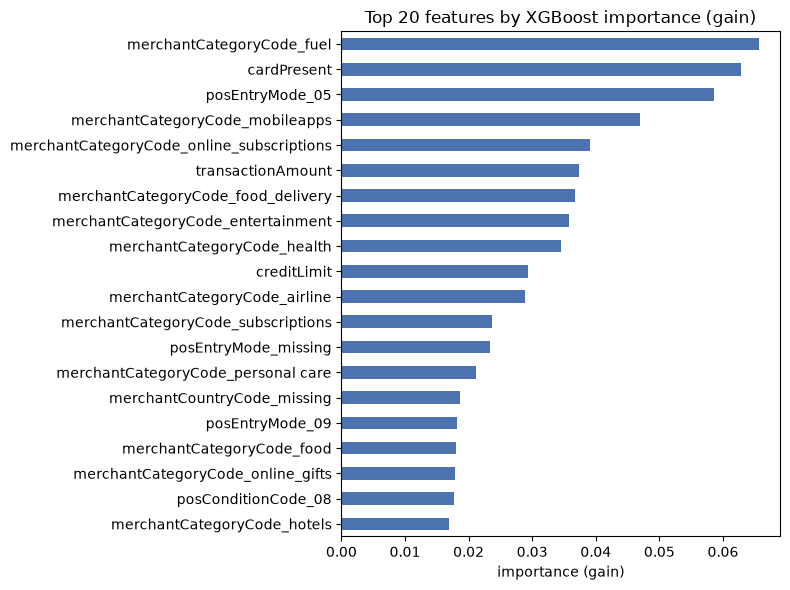

saved reports\figures\feature_importance.png


In [3]:
ohe = pipeline.named_steps["preprocess"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES)) + NUMERIC_FEATURES + BOOLEAN_FEATURES
importances = pd.Series(pipeline.named_steps["model"].feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top[::-1].plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Top 20 features by XGBoost importance (gain)")
ax.set_xlabel("importance (gain)")
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_importance.png", dpi=120)
plt.show()
print("saved", (FIG_DIR / "feature_importance.png").relative_to(REPO_ROOT))


## 3. Figure 2 - Confusion matrix at the operating threshold

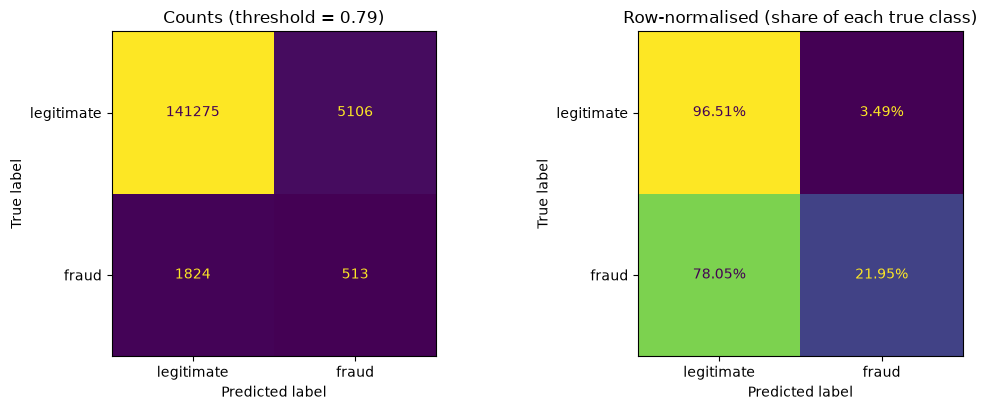

caught 513 of 2,337 frauds (22.0%);  5,106 false alarms out of 146,381 legitimate transactions (3.5%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["legitimate", "fraud"], ax=axes[0], colorbar=False,
)
axes[0].set_title(f"Counts (threshold = {threshold:.2f})")
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["legitimate", "fraud"], ax=axes[1],
    normalize="true", colorbar=False, values_format=".2%",
)
axes[1].set_title("Row-normalised (share of each true class)")
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=120)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f"caught {tp:,} of {tp + fn:,} frauds ({tp / (tp + fn):.1%});  "
      f"{fp:,} false alarms out of {tn + fp:,} legitimate transactions "
      f"({fp / (tn + fp):.1%})")


## 4. Figure 3 - Precision-recall curve (and ROC for reference)

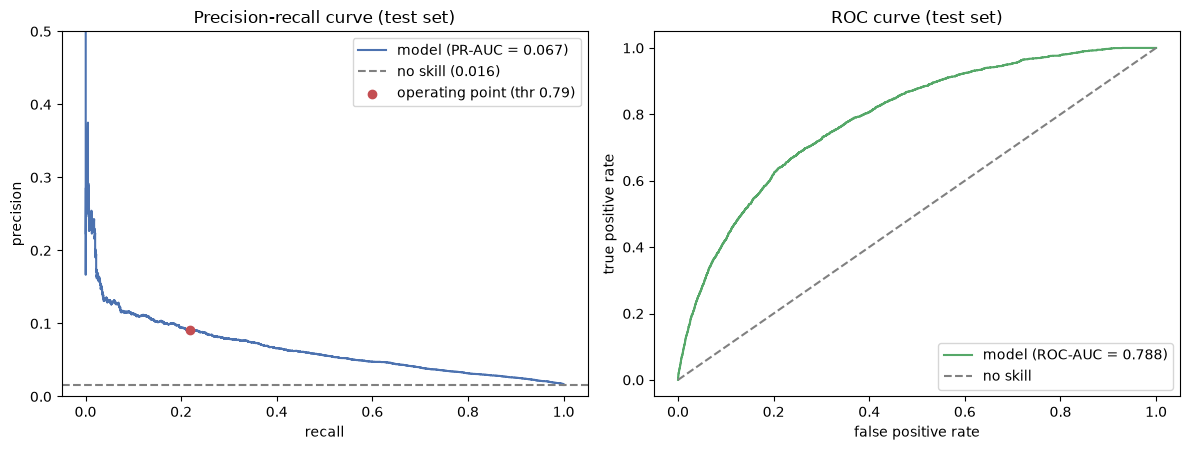

saved reports\figures\pr_curve.png


In [5]:
prec, rec, thr = precision_recall_curve(y_test, test_proba)
op_prec = precision_score(y_test, test_pred)
op_rec = recall_score(y_test, test_pred)

fpr, tpr, _ = roc_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].plot(rec, prec, color="#4C72B0", label=f"model (PR-AUC = {pr_auc:.3f})")
axes[0].axhline(no_skill, color="grey", ls="--", label=f"no skill ({no_skill:.3f})")
axes[0].scatter([op_rec], [op_prec], color="#C44E52", zorder=5,
                label=f"operating point (thr {threshold:.2f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Precision-recall curve (test set)")
axes[0].legend(loc="upper right"); axes[0].set_ylim(0, 0.5)

axes[1].plot(fpr, tpr, color="#55A868", label=f"model (ROC-AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", label="no skill")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (test set)")
axes[1].legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIG_DIR / "pr_curve.png", dpi=120)
plt.show()
print("saved", (FIG_DIR / "pr_curve.png").relative_to(REPO_ROOT))


## 5. Business summary

**The task.** Given a year of credit card transactions, flag the ones likely to
be fraud so a review team can look at them first.

**The data.** 786,363 synthetic transactions from 5,000 accounts (Capital One's
public recruiting dataset). Fraud is rare: about 1.6% of transactions. Before
modelling, roughly 5% of rows were removed as duplicates: purchases that were
later reversed (about $2.7M that nets to zero) and point-of-sale multi-swipe
retries (about $1.1M of repeated charges).

**The model.** A gradient-boosted tree model (XGBoost) trained on transaction
amount and balances, timing, account age, address-change recency, a CVV-mismatch
flag, and merchant and point-of-sale categories. Account and card numbers were
excluded as identifiers, not signal.

**How well it works.**

| Measure | Result | Plain meaning |
| --- | --- | --- |
| ROC-AUC | ~0.78 | Given one real fraud and one legitimate charge, the model scores the fraud higher about 78% of the time. |
| PR-AUC | ~4x the no-skill baseline | Much better than guessing, but precision is still low because fraud is so rare. |
| At the current threshold | recall ~0.22, precision ~0.09 | Catches about 1 in 5 frauds; about 1 in 11 flagged transactions is actually fraud. |

**What this means in practice.** As an MVP the model clearly finds signal and
would let a review team prioritise, but it is not accurate enough to act on
automatically. The threshold is a dial: lower it to catch more fraud at the cost
of more false alarms, raise it for the reverse. Where to set it is a business
decision that depends on the cost of a missed fraud versus the cost of a review.

**Biggest limitation.** No merchant-level history and no per-account behavioural
baseline yet. Those are usually the strongest fraud features and are the first
thing to add.


## 6. Methods considered

- **Algorithm.** XGBoost was chosen for the baseline. A Random Forest was also
  built; it scored slightly lower and produced a ~340 MB model file versus
  ~0.4 MB for XGBoost, which matters for deploying the demo app. Logistic
  regression would be a useful linear reference point but was not run.
- **Class imbalance.** Handled with `scale_pos_weight` (cost reweighting inside
  XGBoost). The main alternative, SMOTE (synthetic oversampling of the fraud
  class from `imbalanced-learn`), was not compared head to head. Both are
  standard; which wins here is an open question.
- **Threshold.** Set by maximising F1 on a validation split. Alternatives:
  target a fixed recall (for example "catch 50% of fraud"), or minimise expected
  cost given a dollar value for a missed fraud and for a review.
- **Features left out.** `merchantName` (~2,500 values) was dropped to keep the
  MVP simple; target encoding would bring it back. No rolling per-account
  aggregates (spend in the last hour or day, distance from the account's usual
  merchants or amounts) were built.
- **Evaluation.** A single stratified train/validation/test split was used.
  k-fold cross-validation would give a more stable read and confidence bands.


## 7. Future work

1. **Add behavioural features:** per-account rolling counts and sums, time since
   the account's previous transaction, deviation from the account's typical
   amount and merchant mix.
2. **Bring back `merchantName`** with target or frequency encoding.
3. **Compare imbalance strategies** properly: `scale_pos_weight` vs. SMOTE vs.
   undersampling, on the same splits.
4. **Tune hyperparameters** with k-fold cross-validation (tree depth, learning
   rate, number of trees, regularisation).
5. **Benchmark alternatives:** LightGBM, a calibrated Random Forest, and a
   logistic-regression baseline.
6. **Choose the threshold from a cost matrix** agreed with the business.
7. **Calibrate probabilities** (Platt or isotonic) so the score reads as a real
   probability.
8. **Deploy the Streamlit app** to Streamlit Community Cloud and add batch
   scoring of an uploaded file.


## Figures written

- `reports/figures/feature_importance.png`
- `reports/figures/confusion_matrix.png`
- `reports/figures/pr_curve.png`
